--- Starting Network Growth Model for n=100 ---
Total target nodes (n): 100
Initial 'seed' nodes (m0): 3
Edges each new node adds (m): 2

Visualizing initial 'seed' network...
Adding 97 nodes via Preferential Attachment...
Visualizing final network and hubs...


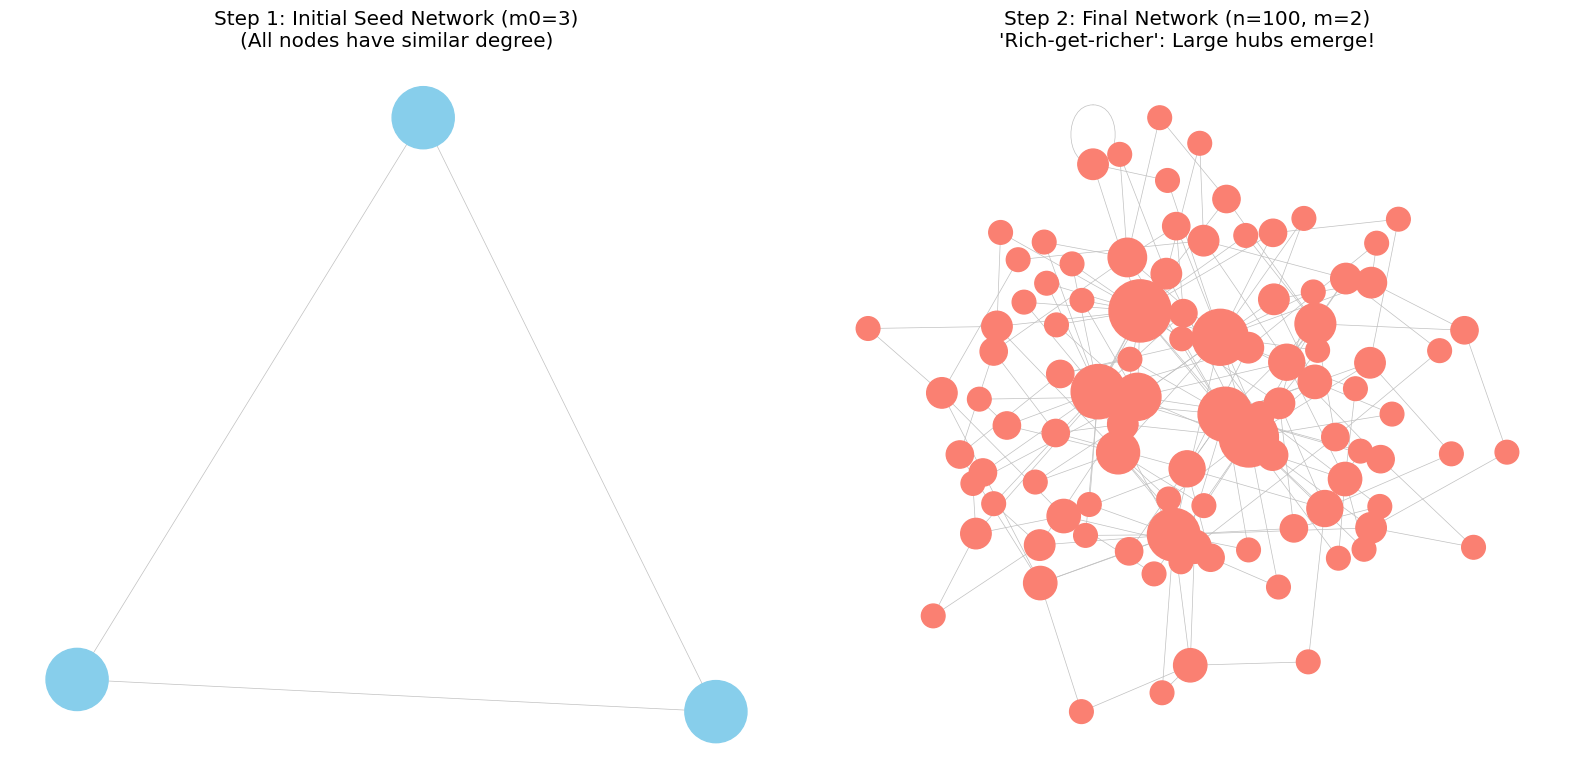


Top 5 degrees in final network: [20, 18, 16, 15, 15]


In [2]:
import random
import networkx as nx
import matplotlib.pyplot as plt

# Increase font size for clarity in plots
plt.rcParams.update({'font.size': 12})

def visualize_network(G, title, subplot_position, node_color):
    """
    Helper function to plot the graph with node sizes
    proportional to their degrees to visually show hubs.
    """
    ax = plt.subplot(subplot_position)

    # Calculate degrees to scale node sizes
    d_dict = dict(G.degree())
    # Scale: minimum size of 100, max size of 2000 based on max degree
    max_d = max(d_dict.values()) if d_dict else 1
    node_sizes = [100 + (d_dict[n] / max_d) * 1900 for n in G.nodes()]

    pos = nx.spring_layout(G)
    nx.draw(G, pos, ax=ax, with_labels=False, node_color=node_color,
            node_size=node_sizes, edge_color='silver', width=0.5)
    ax.set_title(title)
    ax.axis('off')

def implement_rich_gets_richer(n_total):
    """
    Implements the Barabasi-Albert (BA) model and visualizes the
    transformation from egalitarian seed to scale-free structure.

    Formula for Preferential Attachment:
    Probability(P_i) = degree(i) / sum(all degrees)
    """

    print(f"--- Starting Network Growth Model for n={n_total} ---")

    # Setup Figure for side-by-side comparison
    fig = plt.figure(figsize=(16, 8))

    # --- STEPS FOR IMPLEMENTATION ---

    # 1. Decide m0 and m based on n
    # m0: Initial number of nodes (random between 2 and n/5)
    m0 = random.randint(3, max(4, n_total // 5)) # Slightly larger seed for visual impact
    m = m0 - 1 # Edges to connect per new node (m <= m0)

    print(f"Total target nodes (n): {n_total}")
    print(f"Initial 'seed' nodes (m0): {m0}")
    print(f"Edges each new node adds (m): {m}\n")

    # 2. Initialize the network with m0 nodes.
    # We use a cycle graph to meet the 'at least one link' condition evenly.
    G = nx.cycle_graph(m0)

    # --- VISUALIZATION 1: THE SEED NETWORK (BEFORE GROWTH) ---
    print("Visualizing initial 'seed' network...")
    visualize_network(G, f"Step 1: Initial Seed Network (m0={m0})\n(All nodes have similar degree)", 121, 'skyblue')

    # --- GROWTH AND PREFERENTIAL ATTACHMENT ---

    # Loop to add the rest n - m0 nodes
    print(f"Adding {n_total - m0} nodes via Preferential Attachment...")
    for new_node in range(m0, n_total):
        edges_added = 0
        targets = set()

        while edges_added < m:
            # Step: Preprocessing (Get degrees and calculate probabilities)
            nodes = list(G.nodes())
            degrees = dict(G.degree())
            total_degree = sum(degrees.values())

            # The heart of the BA model:
            # Formula: probability[i] = Degree(i) / Sum(degrees)
            probabilities = [degrees[node] / total_degree for node in nodes]

            # Maintain cumulative probabilities for weighted selection
            # Ex: [0.2, 0.3, 0.5] -> [0.2, 0.5, 1.0]
            cumulative_probs = []
            cumulative_sum = 0
            for p in probabilities:
                cumulative_sum += p
                cumulative_probs.append(cumulative_sum)

            # Step: Choose a random number from 0 to 1
            r = random.random()

            # Decide the edge based on preferential attachment:
            # Pick whichever node has cumulative probability exceeding this random number.
            chosen_node = None
            for i, cp in enumerate(cumulative_probs):
                if r <= cp:
                    chosen_node = nodes[i]
                    break

            # Ensure no self-loops or duplicate edges for one new node
            if chosen_node not in targets:
                G.add_edge(new_node, chosen_node)
                targets.add(chosen_node)
                edges_added += 1

    # --- VISUALIZATION 2: THE FINAL NETWORK (AFTER GROWTH) ---
    print("Visualizing final network and hubs...")
    visualize_network(G, f"Step 2: Final Network (n={n_total}, m={m})\n'Rich-get-richer': Large hubs emerge!", 122, 'salmon')

    plt.tight_layout()
    plt.show()

    return G

# --- Execution ---
# Set the total nodes (higher number makes the hubs more dramatic)
n = 100
social_network = implement_rich_gets_richer(n)

# Optional: Print top degrees to verify
degrees = [d for n, d in social_network.degree()]
top_degrees = sorted(degrees, reverse=True)[:5]
print(f"\nTop 5 degrees in final network: {top_degrees}")